In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

#### 1. Функция Распределения

In [3]:
data_path = Path(".")

magn = np.loadtxt(data_path / "magn.txt")
deep = np.loadtxt(data_path / "deep.txt")
time = np.loadtxt(data_path / "time.txt")

print(len(magn), len(deep), len(time))

56832 56832 56832


In [4]:
df = pd.DataFrame({
    "magn": magn,
    "deep": deep,
    "time": time
})

df.head()

,magn,deep,time
0,6.2,59.0,0.0
1,6.0,95.0,349317.0
2,5.7,33.0,502720.0
3,6.1,168.0,771896.0
4,6.0,33.0,1079980.0


In [5]:
df = df.sort_values("time").reset_index(drop=True)

df["dt"] = df["time"].diff()

# исключаем первое событие, у которого нет предыдущего
df = df.iloc[1:].reset_index(drop=True)

df.head()

,magn,deep,time,dt
0,6.0,95.0,349317.0,349317.0
1,5.7,33.0,502720.0,153403.0
2,6.1,168.0,771896.0,269176.0
3,6.0,33.0,1079980.0,308084.0
4,6.3,69.0,1175215.0,95235.0


In [6]:
print("Количество событий после исключения первого:", len(df))
print("Минимальный dt:", df["dt"].min())
print("Количество отрицательных dt:", (df["dt"] < 0).sum())
print("Количество нулевых dt:", (df["dt"] == 0).sum())

Количество событий после исключения первого: 56831
Минимальный dt: 0.0
Количество отрицательных dt: 0
Количество нулевых dt: 4


In [7]:
magn_step = 0.5      # магнитуда
deep_step = 5        # км
dt_step = 5000       # секунд

def make_bins(x, step):
    left = np.floor(x.min() / step) * step
    right = np.ceil(x.max() / step) * step
    return np.arange(left, right + step, step)

magn_bins = make_bins(df["magn"], magn_step)
deep_bins = make_bins(df["deep"], deep_step)
dt_bins = make_bins(df["dt"], dt_step)

print("Интервал магнитуд:", magn_bins[0], "-", magn_bins[-1])
print("Интервал глубин:", deep_bins[0], "-", deep_bins[-1])
print("Интервал dt:", dt_bins[0], "-", dt_bins[-1])

print("Число интервалов по магнитуде:", len(magn_bins) - 1)
print("Число интервалов по глубине:", len(deep_bins) - 1)
print("Число интервалов по dt:", len(dt_bins) - 1)

Интервал магнитуд: 0.0 - 9.0
Интервал глубин: -5.0 - 690.0
Интервал dt: 0.0 - 1990000.0
Число интервалов по магнитуде: 18
Число интервалов по глубине: 139
Число интервалов по dt: 398


In [8]:
def build_distribution_function(data, magn_bins, deep_bins, dt_bins):
    """
    Строит эмпирическую функцию распределения F(m, d, dt)
    на заданной сетке.

    Возвращает:
    counts — количество событий в каждой ячейке
    probs  — вероятности попадания в ячейки
    F      — функция распределения
    """

    counts, _ = np.histogramdd(
        data[["magn", "deep", "dt"]].values,
        bins=[magn_bins, deep_bins, dt_bins]
    )

    probs = counts / counts.sum()

    F = probs.cumsum(axis=0)
    F = F.cumsum(axis=1)
    F = F.cumsum(axis=2)

    return counts, probs, F

In [9]:
counts_full, probs_full, F_full = build_distribution_function(
    df,
    magn_bins,
    deep_bins,
    dt_bins
)

print("Сумма вероятностей:", probs_full.sum())
print("Максимальное значение функции распределения:", F_full.max())
print("Последнее значение F:", F_full[-1, -1, -1])

Сумма вероятностей: 0.9999999999999999
Максимальное значение функции распределения: 1.0000000000000004
Последнее значение F: 1.0000000000000004


In [10]:
# делим данные на две половины
n = len(df)
mid = n // 2

df_first = df.iloc[:mid].copy()
df_second = df.iloc[mid:].copy()

print("Первая половина:", len(df_first))
print("Вторая половина:", len(df_second))

Первая половина: 28415
Вторая половина: 28416


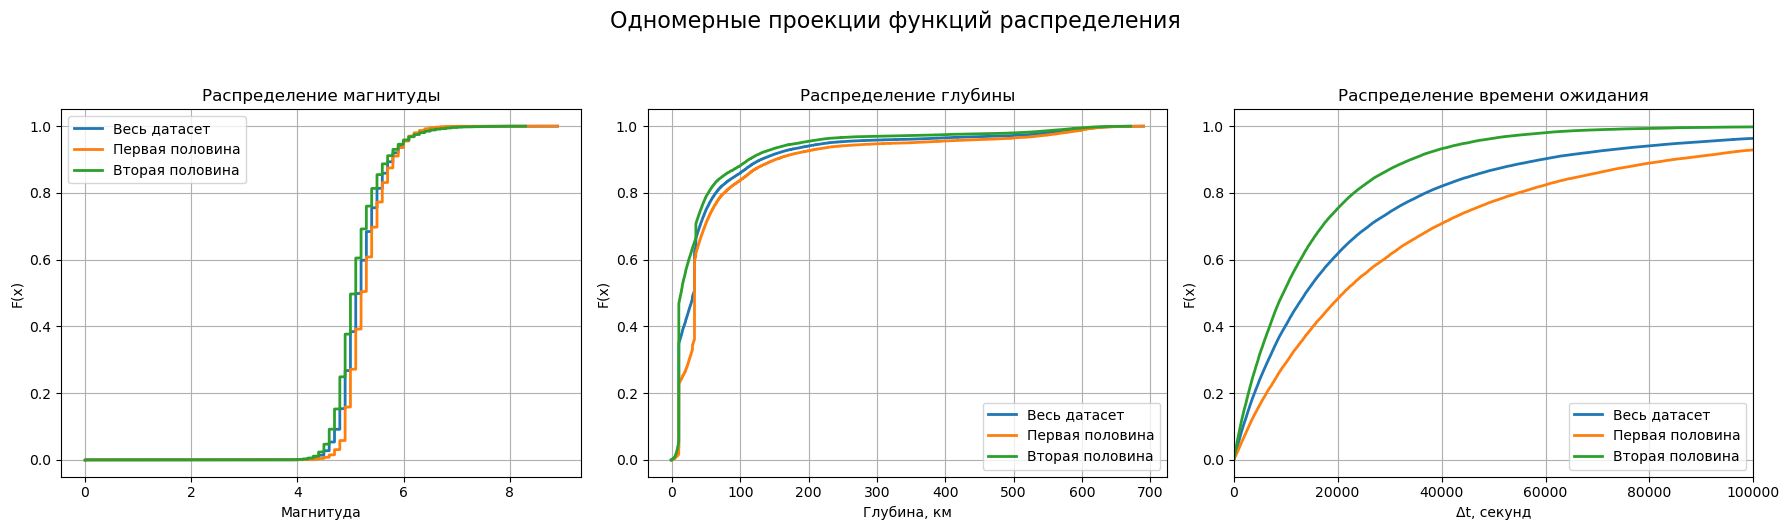

In [11]:
def plot_ecdf_on_ax(ax, data_list, column, xlabel, title, xlim=None):
    for data, label in data_list:
        values = np.sort(data[column].dropna().values)
        y = np.arange(1, len(values) + 1) / len(values)
        
        ax.plot(values, y, linewidth=2, label=label)
    
    if xlim is not None:
        ax.set_xlim(xlim)
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel("F(x)")
    ax.set_title(title)
    ax.grid(True)
    ax.legend()

datasets = [
    (df, "Весь датасет"),
    (df_first, "Первая половина"),
    (df_second, "Вторая половина")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_ecdf_on_ax(
    axes[0],
    datasets,
    column="magn",
    xlabel="Магнитуда",
    title="Распределение магнитуды"
)

plot_ecdf_on_ax(
    axes[1],
    datasets,
    column="deep",
    xlabel="Глубина, км",
    title="Распределение глубины"
)

plot_ecdf_on_ax(
    axes[2],
    datasets,
    column="dt",
    xlabel="Δt, секунд",
    title="Распределение времени ожидания",
    xlim=(0, 100_000)
)

plt.suptitle(
    "Одномерные проекции функций распределения",
    fontsize=16,
    y=1.05
)

plt.tight_layout()
plt.show()

In [12]:
counts_first, probs_first, F_first = build_distribution_function(
    df_first,
    magn_bins,
    deep_bins,
    dt_bins
)

counts_second, probs_second, F_second = build_distribution_function(
    df_second,
    magn_bins,
    deep_bins,
    dt_bins
)

In [13]:
diff_F = F_first - F_second

C_norm = np.max(np.abs(diff_F))

print("C-норма разности функций распределения:", C_norm)

C-норма разности функций распределения: 0.3428614009322097


In [14]:
# Где достигается максимум разности

max_idx = np.unravel_index(
    np.argmax(np.abs(diff_F)),
    diff_F.shape
)

i_max, j_max, k_max = max_idx

print("Индекс максимума:", max_idx)

print("F_first:", F_first[max_idx])
print("F_second:", F_second[max_idx])
print("Разность:", diff_F[max_idx])
print("Модуль разности:", abs(diff_F[max_idx]))

print()
print("M <=", magn_bins[i_max + 1])
print("D <=", deep_bins[j_max + 1])
print("dt <=", dt_bins[k_max + 1])

Индекс максимума: (np.int64(16), np.int64(6), np.int64(7))
F_first: 0.2504311103290516
F_second: 0.5932925112612613
Разность: -0.3428614009322097
Модуль разности: 0.3428614009322097

M <= 8.5
D <= 30.0
dt <= 40000.0


In [15]:
def plot_F_slice(F, magn_bins, deep_bins, dt_bins, depth_limit, dt_limit=150000):
    magn_upper = magn_bins[1:]
    deep_upper = deep_bins[1:]
    dt_upper = dt_bins[1:]

    deep_idx = np.searchsorted(deep_upper, depth_limit)
    deep_idx = min(deep_idx, len(deep_upper) - 1)

    dt_mask = dt_upper <= dt_limit

    F_slice = F[:, deep_idx, :][:, dt_mask]

    plt.figure(figsize=(12, 6))

    plt.imshow(
        F_slice,
        origin="lower",
        aspect="auto",
        extent=[
            dt_upper[dt_mask][0],
            dt_upper[dt_mask][-1],
            magn_upper[0],
            magn_upper[-1]
        ]
    )

    plt.colorbar(label="F(m, d, Δt)")
    plt.xlabel("Время от предыдущего события Δt, секунд")
    plt.ylabel("Магнитуда")
    plt.title(f"Функция распределения при D ≤ {deep_upper[deep_idx]} км")

    plt.show()

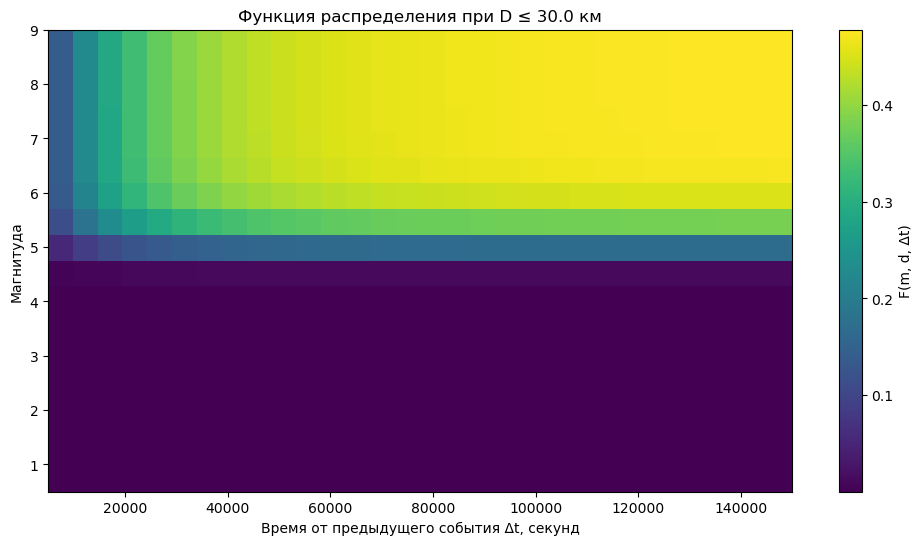

In [16]:
plot_F_slice(
    F_full,
    magn_bins,
    deep_bins,
    dt_bins,
    depth_limit=30,
    dt_limit=150000
)

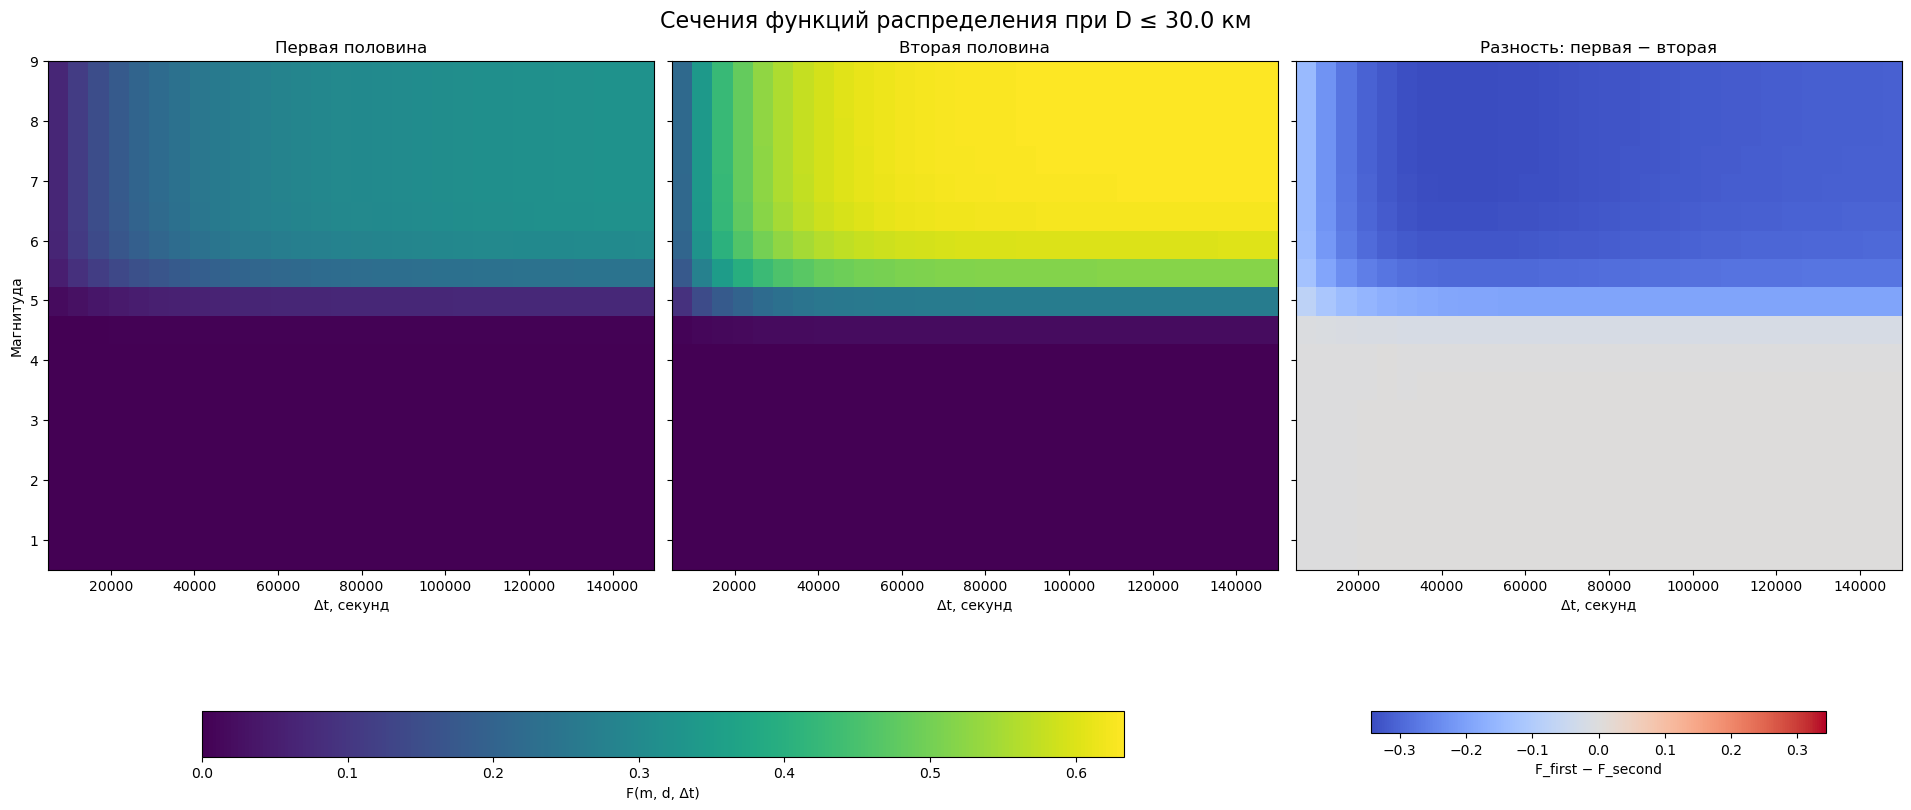

In [17]:
def plot_F_compare_slice_clean(
    F_first,
    F_second,
    magn_bins,
    deep_bins,
    dt_bins,
    depth_limit,
    dt_limit=150_000
):
    magn_upper = magn_bins[1:]
    deep_upper = deep_bins[1:]
    dt_upper = dt_bins[1:]

    deep_idx = np.searchsorted(deep_upper, depth_limit)
    deep_idx = min(deep_idx, len(deep_upper) - 1)

    dt_mask = dt_upper <= dt_limit

    F1 = F_first[:, deep_idx, :][:, dt_mask]
    F2 = F_second[:, deep_idx, :][:, dt_mask]
    diff = F1 - F2

    extent = [
        dt_upper[dt_mask][0],
        dt_upper[dt_mask][-1],
        magn_upper[0],
        magn_upper[-1]
    ]

    fig, axes = plt.subplots(
        1, 3,
        figsize=(19, 8),
        sharey=True,
        constrained_layout=True
    )

    vmax_F = max(F1.max(), F2.max())

    im1 = axes[0].imshow(
        F1,
        origin="lower",
        aspect="auto",
        extent=extent,
        vmin=0,
        vmax=vmax_F
    )

    axes[0].set_title("Первая половина")
    axes[0].set_xlabel("Δt, секунд")
    axes[0].set_ylabel("Магнитуда")

    im2 = axes[1].imshow(
        F2,
        origin="lower",
        aspect="auto",
        extent=extent,
        vmin=0,
        vmax=vmax_F
    )

    axes[1].set_title("Вторая половина")
    axes[1].set_xlabel("Δt, секунд")

    vmax_diff = np.max(np.abs(diff))

    im3 = axes[2].imshow(
        diff,
        origin="lower",
        aspect="auto",
        extent=extent,
        vmin=-vmax_diff,
        vmax=vmax_diff,
        cmap="coolwarm"
    )

    axes[2].set_title("Разность: первая − вторая")
    axes[2].set_xlabel("Δt, секунд")

    cbar1 = fig.colorbar(
        im2,
        ax=axes[:2],
        orientation="horizontal",
        shrink=0.75,
        pad=0.16
    )
    cbar1.set_label("F(m, d, Δt)")

    cbar2 = fig.colorbar(
        im3,
        ax=axes[2],
        orientation="horizontal",
        shrink=0.75,
        pad=0.16
    )
    cbar2.set_label("F_first − F_second")

    fig.suptitle(
        f"Сечения функций распределения при D ≤ {deep_upper[deep_idx]} км",
        fontsize=16
    )

    plt.show()

depth_of_max = deep_bins[j_max + 1]

plot_F_compare_slice_clean(
    F_first,
    F_second,
    magn_bins,
    deep_bins,
    dt_bins,
    depth_limit=depth_of_max,
    dt_limit=150_000
)

In [18]:
summary = pd.DataFrame({
    "Параметр": [
        "Средняя магнитуда",
        "Медианная магнитуда",
        "Средняя глубина, км",
        "Медианная глубина, км",
        "Среднее dt, сек",
        "Медианное dt, сек",
        "Доля D <= 30 км",
        "Доля dt <= 40000 сек",
        "Доля D <= 30 км и dt <= 40000 сек"
    ],
    "Первая половина": [
        df_first["magn"].mean(),
        df_first["magn"].median(),
        df_first["deep"].mean(),
        df_first["deep"].median(),
        df_first["dt"].mean(),
        df_first["dt"].median(),
        (df_first["deep"] <= 30).mean(),
        (df_first["dt"] <= 40000).mean(),
        ((df_first["deep"] <= 30) & (df_first["dt"] <= 40000)).mean()
    ],
    "Вторая половина": [
        df_second["magn"].mean(),
        df_second["magn"].median(),
        df_second["deep"].mean(),
        df_second["deep"].median(),
        df_second["dt"].mean(),
        df_second["dt"].median(),
        (df_second["deep"] <= 30).mean(),
        (df_second["dt"] <= 40000).mean(),
        ((df_second["deep"] <= 30) & (df_second["dt"] <= 40000)).mean()
    ]
})

summary["Разность: вторая - первая"] = (
    summary["Вторая половина"] - summary["Первая половина"]
)

summary

,Параметр,Первая половина,Вторая половина,Разность: вторая - первая
0,Средняя магнитуда,5.303442,5.131437,-0.172005
1,Медианная магнитуда,5.200000,5.100000,-0.100000
2,"Средняя глубина, км",71.135826,48.994704,-22.141122
3,"Медианная глубина, км",33.000000,13.100000,-19.900000
4,"Среднее dt, сек",35556.246278,14422.080412,-21134.165866
5,"Медианное dt, сек",21077.000000,9539.500000,-11537.500000
6,Доля D <= 30 км,0.344783,0.635381,0.290599
7,Доля dt <= 40000 сек,0.708042,0.932256,0.224215
8,Доля D <= 30 км и dt <= 40000 сек,0.263558,0.595193,0.331635


Значение C-нормы разности функций распределения получилось примерно равным 0.343. Это означает, что первая и вторая половина данных заметно отличаются: в некоторой области пространства параметров накопленные вероятности различаются примерно на 34 процентных пункта.

Максимум разности достигается при условиях:

M ≤ 8.5, D ≤ 30 км, Δt ≤ 40000 секунд.

Так как почти все события имеют магнитуду меньше 8.5, основное отличие связано не с магнитудой, а с глубиной и временем ожидания между событиями.

В первой половине доля событий, удовлетворяющих этим условиям, равна примерно 25.0%, а во второй половине — примерно 59.3%. Следовательно, во второй половине данных существенно выросла доля неглубоких землетрясений с малым временем ожидания после предыдущего события.

Это указывает на нестационарность процесса: статистические свойства землетрясений во второй половине отличаются от первой.

#### 2. Матрица корреляции

In [19]:
features = ["magn", "deep", "dt"]

def correlation_analysis(data, name):
    corr_matrix = data[features].corr(method="pearson")
    
    # так как корреляционная матрица симметричная,
    # лучше использовать eigvalsh
    eigenvalues = np.linalg.eigvalsh(corr_matrix.values)
    eigenvalues = eigenvalues[::-1]  # сортируем по убыванию
    
    print(f"\n{name}")
    print("Корреляционная матрица:")
    display(corr_matrix.round(4))
    
    print("Собственные значения:")
    display(pd.DataFrame({
        "eigenvalue": eigenvalues
    }).round(4))
    
    print("Сумма собственных значений:", eigenvalues.sum().round(4))
    
    return corr_matrix, eigenvalues

In [20]:
corr_full, eig_full = correlation_analysis(df, "Полный массив")
corr_first, eig_first = correlation_analysis(df_first, "Первая половина")
corr_second, eig_second = correlation_analysis(df_second, "Вторая половина")


Полный массив
Корреляционная матрица:


,magn,deep,dt
magn,1.0000,0.1064,0.1169
deep,0.1064,1.0000,0.0692
dt,0.1169,0.0692,1.0000


Собственные значения:


,eigenvalue
0,1.1963
1,0.9313
2,0.8724


Сумма собственных значений: 3.0

Первая половина
Корреляционная матрица:


...

Сумма собственных значений: 3.0

Вторая половина
Корреляционная матрица:


,magn,deep,dt
magn,1.0000,0.1189,0.0115
deep,0.1189,1.0000,0.0410
dt,0.0115,0.0410,1.0000


Собственные значения:


,eigenvalue
0,1.1297
1,0.9930
2,0.8774


Сумма собственных значений: 3.0


In [21]:
import numpy as np
import matplotlib.pyplot as plt

def plot_corr_matrices_offdiag(corr_matrices, titles, features):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # общий масштаб только по внедиагональным элементам
    all_offdiag_values = []

    for corr in corr_matrices:
        values = corr.values.copy()
        np.fill_diagonal(values, np.nan)
        all_offdiag_values.extend(values[~np.isnan(values)])

    vmax = np.max(np.abs(all_offdiag_values))
    vmax = max(vmax, 0.01)

    cmap = plt.cm.coolwarm.copy()
    cmap.set_bad(color="lightgray")

    for ax, corr, title in zip(axes, corr_matrices, titles):
        values = corr.values.copy()
        np.fill_diagonal(values, np.nan)

        im = ax.imshow(
            values,
            vmin=-vmax,
            vmax=vmax,
            cmap=cmap
        )

        ax.set_title(title)
        ax.set_xticks(range(len(features)))
        ax.set_yticks(range(len(features)))
        ax.set_xticklabels(features)
        ax.set_yticklabels(features)

        for i in range(len(features)):
            for j in range(len(features)):
                if i == j:
                    ax.text(j, i, "—", ha="center", va="center", color="black")
                else:
                    ax.text(
                        j, i,
                        f"{corr.iloc[i, j]:.2f}",
                        ha="center",
                        va="center",
                        color="black"
                    )

    cbar = fig.colorbar(im, ax=axes, shrink=0.85)
    cbar.set_label("Коэффициент корреляции без диагонали")

    fig.suptitle("Корреляционные матрицы без диагональных элементов", fontsize=15)
    plt.show()

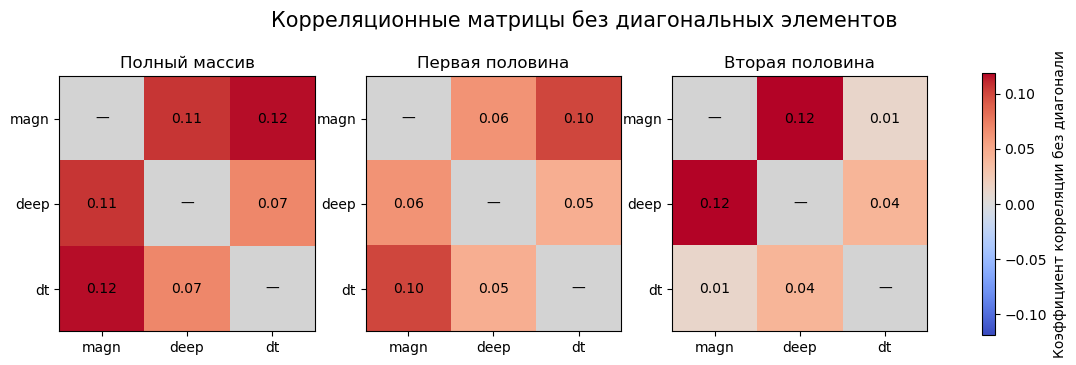

In [22]:
plot_corr_matrices_offdiag(
    corr_matrices=[corr_full, corr_first, corr_second],
    titles=["Полный массив", "Первая половина", "Вторая половина"],
    features=features
)

Диагональные элементы корреляционной матрицы были исключены из визуализации, так как они всегда равны $1$ и не несут информации о связи разных параметров. После удаления диагонали видно, что все попарные корреляции остаются малыми: по модулю они не превышают примерно $0.12$. Следовательно, сильной линейной зависимости между магнитудой, глубиной и временем ожидания не наблюдается.

In [23]:
eig_table = pd.DataFrame({
    "Полный массив": eig_full,
    "Первая половина": eig_first,
    "Вторая половина": eig_second
}, index=["λ1", "λ2", "λ3"])

eig_table.round(4)

,Полный массив,Первая половина,Вторая половина
λ1,1.1963,1.1410,1.1297
λ2,0.9313,0.9604,0.9930
λ3,0.8724,0.8986,0.8774


In [24]:
def eig_vectors_analysis(corr_matrix, features):
    eigenvalues, eigenvectors = np.linalg.eigh(corr_matrix.values)

    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    if eigenvectors[:, 0].sum() < 0:
        eigenvectors[:, 0] *= -1

    eig_vectors = pd.DataFrame(
        eigenvectors,
        index=features,
        columns=["v1", "v2", "v3"]
    )

    eig_values = pd.DataFrame({
        "eigenvalue": eigenvalues,
        "share": eigenvalues / eigenvalues.sum()
    }, index=["λ1", "λ2", "λ3"])

    return eig_values, eig_vectors


eig_values_full, eig_vectors_full = eig_vectors_analysis(corr_full, features)

display(eig_values_full.round(4))
display(eig_vectors_full.round(4))

,eigenvalue,share
λ1,1.1963,0.3988
λ2,0.9313,0.3104
λ3,0.8724,0.2908


,v1,v2,v3
magn,0.6271,0.0662,-0.7761
deep,0.5382,-0.7572,0.3702
dt,0.5631,0.6499,0.5104




Корреляционная матрица $R$ описывает линейные связи между стандартизованными признаками: магнитудой $M$, глубиной $D$ и временем ожидания $\Delta t$.

Для полного массива корреляционная матрица имеет слабые внедиагональные элементы: все коэффициенты корреляции по модулю не превышают примерно $0.12$. Это означает, что сильной линейной зависимости между параметрами не наблюдается.

Собственные значения корреляционной матрицы полного массива получились примерно равными:

$`
\lambda_1 \approx 1.196,\quad
\lambda_2 \approx 0.931,\quad
\lambda_3 \approx 0.872.
`$

Их сумма равна $3$, потому что корреляционная матрица построена для трёх переменных, а на её диагонали стоят единицы:

$`
\lambda_1 + \lambda_2 + \lambda_3 = \operatorname{tr}(R) = 1 + 1 + 1 = 3.
`$

Собственный вектор, соответствующий наибольшему собственному значению, имеет вид:

$`
v_1 \approx (0.627,\; 0.538,\; 0.563).
`$

То есть первое направление примерно соответствует совместному изменению всех трёх стандартизованных параметров:

$`
v_1 \approx 0.627 M + 0.538 D + 0.563 \Delta t.
`$

Смысл собственного значения можно объяснить через дисперсию проекции. Если взять направление $u$ такое, что $\|u\| = 1$, то дисперсия данных при проекции на это направление равна:

$`
\operatorname{Var}(Xu) = u^T R u.
`$

Если $u$ является собственным вектором корреляционной матрицы, то $Ru = \lambda u$. Тогда:

$`
u^T R u = u^T \lambda u = \lambda u^T u = \lambda.
`$

Так как $u^T u = 1$, собственное значение $\lambda$ равно дисперсии данных вдоль соответствующего собственного направления.

Поэтому если одно собственное значение сильно больше остальных, то соответствующий собственный вектор задаёт доминирующее линейное направление в данных. В нашем случае $\lambda_1 \approx 1.196$ лишь немного больше $1$, а остальные собственные значения тоже близки к $1$. Значит, выраженного доминирующего направления нет.

Первое направление объясняет примерно:

$`
\frac{\lambda_1}{3} \approx \frac{1.196}{3} \approx 0.399,
`$

то есть около $40\%$ суммарной линейной изменчивости. При полностью независимых признаках каждое направление объясняло бы около $33.3\%$. Разница небольшая, поэтому по результатам корреляционного анализа можно сделать вывод, что магнитуда, глубина и время ожидания практически не коррелируют между собой.

In [53]:
import numpy as np
import matplotlib.pyplot as plt

def standardize_columns(data, columns):
    X = data[columns].values.astype(float)
    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=1)
    X_std = (X - mean) / std
    return X_std

def plot_pairwise_pca_pretty(
    data,
    sample_size=6000,
    q_low=0.007,
    q_high=0.999
):
    pairs = [
        ("magn", "deep", "M", "D"),
        ("magn", "dt", "M", "Δt"),
        ("deep", "dt", "D", "Δt")
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

    point_colors = ["steelblue", "darkorange", "seagreen"]
    pc1_color = "crimson"
    pc2_color = "purple"

    for ax, (x_col, y_col, x_lab, y_lab), pts_color in zip(axes, pairs, point_colors):
        X = standardize_columns(data, [x_col, y_col])

        # PCA считаем по полным данным
        R = np.corrcoef(X, rowvar=False)
        eigvals, eigvecs = np.linalg.eigh(R)

        order = np.argsort(eigvals)[::-1]
        eigvals = eigvals[order]
        eigvecs = eigvecs[:, order]

        # Обрезаем только для визуализации
        x_min, x_max = np.quantile(X[:, 0], [q_low, q_high])
        y_min, y_max = np.quantile(X[:, 1], [q_low, q_high])

        mask = (
            (X[:, 0] >= x_min) & (X[:, 0] <= x_max) &
            (X[:, 1] >= y_min) & (X[:, 1] <= y_max)
        )

        X_plot = X[mask]

        if len(X_plot) > sample_size:
            idx = np.random.choice(len(X_plot), sample_size, replace=False)
            X_plot = X_plot[idx]

        # Облако точек
        ax.scatter(
            X_plot[:, 0],
            X_plot[:, 1],
            s=10,
            alpha=0.18,
            color=pts_color
        )

        # Главные направления
        for k, color, name in [(0, pc1_color, "PC1"), (1, pc2_color, "PC2")]:
            v = eigvecs[:, k]
            lam = eigvals[k]
            L = 2.4 * np.sqrt(lam)

            ax.arrow(
                0, 0,
                L * v[0], L * v[1],
                color=color,
                linewidth=2.8,
                head_width=0.12,
                length_includes_head=True
            )
            ax.arrow(
                0, 0,
                -L * v[0], -L * v[1],
                color=color,
                linewidth=2.2,
                head_width=0.12,
                length_includes_head=True
            )

            ax.text(
                1.08 * L * v[0],
                1.08 * L * v[1],
                f"{name}, λ={lam:.3f}",
                color=color,
                fontsize=11,
                weight="bold"
            )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

        ax.set_xlabel(f"{x_lab}_std")
        ax.set_ylabel(f"{y_lab}_std")
        ax.set_title(f"{x_lab} vs {y_lab}")
        ax.grid(True, alpha=0.35)

    plt.suptitle(
        "Весь датасет: 2D-проекции и главные направления\n"
        "(обрезка выбросов только для визуализации)",
        fontsize=15
    )
    plt.show()

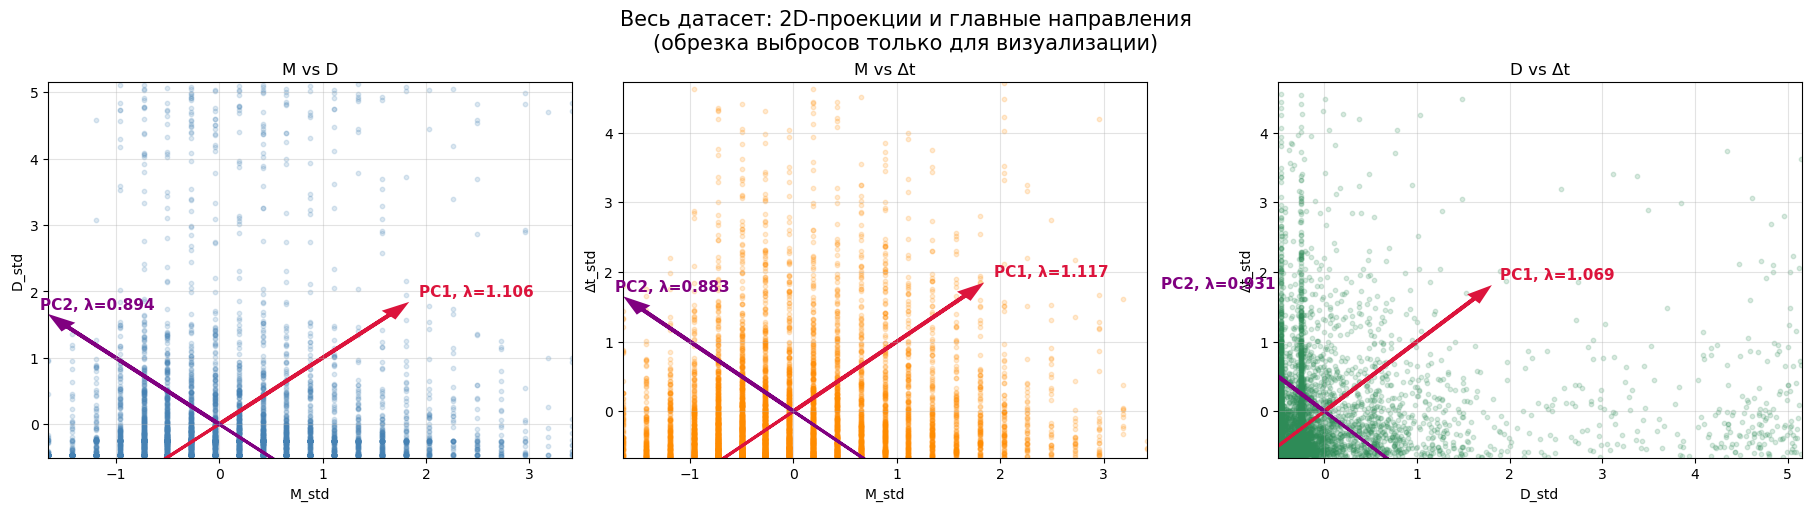

In [49]:
plot_pairwise_pca_pretty(df)

In [37]:
import numpy as np
import plotly.graph_objects as go

def plot_pca_3d_plotly(data, title="3D PCA"):
    cols = ["magn", "deep", "dt"]
    X = data[cols].values.astype(float)

    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=1)
    X = (X - mean) / std

    R = np.corrcoef(X, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(R)

    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    if len(X) > 5000:
        idx = np.random.choice(len(X), 5000, replace=False)
        X_plot = X[idx]
    else:
        X_plot = X

    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=X_plot[:, 0],
        y=X_plot[:, 1],
        z=X_plot[:, 2],
        mode="markers",
        marker=dict(size=2, opacity=0.25),
        name="data"
    ))

    for k in range(3):
        v = eigvecs[:, k]
        lam = eigvals[k]
        L = 3 * np.sqrt(lam)

        fig.add_trace(go.Scatter3d(
            x=[-L*v[0], L*v[0]],
            y=[-L*v[1], L*v[1]],
            z=[-L*v[2], L*v[2]],
            mode="lines",
            line=dict(width=6),
            name=f"PC{k+1}"
        ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="M_std",
            yaxis_title="D_std",
            zaxis_title="dt_std"
        ),
        width=800,
        height=700
    )

    fig.show()

In [38]:
plot_pca_3d_plotly(df)

In [56]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt

def plot_pca_3d_two_views(
    data,
    sample_size=7000,
    q_low=0.01,
    q_high=0.99,
    arrow_scale=2.3
):
    cols = ["magn", "deep", "dt"]
    X = data[cols].values.astype(float)

    # стандартизация
    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=1)
    X_std = (X - mean) / std

    # PCA считаем по всему датасету
    R = np.corrcoef(X_std, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(R)

    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # обрезаем только для визуализации
    x_min, x_max = np.quantile(X_std[:, 0], [q_low, q_high])
    y_min, y_max = np.quantile(X_std[:, 1], [q_low, q_high])
    z_min, z_max = np.quantile(X_std[:, 2], [q_low, q_high])

    mask = (
        (X_std[:, 0] >= x_min) & (X_std[:, 0] <= x_max) &
        (X_std[:, 1] >= y_min) & (X_std[:, 1] <= y_max) &
        (X_std[:, 2] >= z_min) & (X_std[:, 2] <= z_max)
    )
    X_plot = X_std[mask]

    if len(X_plot) > sample_size:
        idx = np.random.choice(len(X_plot), sample_size, replace=False)
        X_plot = X_plot[idx]

    # берём 2 верхних ракурса
    views = [
        (18, -120, "Ракурс 1"),
        (18, -35, "Ракурс 2")
    ]

    colors = ["crimson", "darkorange", "seagreen"]
    labels = [f"PC1, λ={eigvals[0]:.3f}",
              f"PC2, λ={eigvals[1]:.3f}",
              f"PC3, λ={eigvals[2]:.3f}"]

    fig = plt.figure(figsize=(15, 6))

    for i, (elev, azim, subtitle) in enumerate(views, 1):
        ax = fig.add_subplot(1, 2, i, projection="3d")

        # облако точек
        ax.scatter(
            X_plot[:, 0], X_plot[:, 1], X_plot[:, 2],
            s=8, alpha=0.12, color="steelblue"
        )

        # главные направления
        for k in range(3):
            v = eigvecs[:, k]
            L = arrow_scale * np.sqrt(eigvals[k])

            ax.quiver(
                0, 0, 0,
                L * v[0], L * v[1], L * v[2],
                color=colors[k],
                linewidth=3.2,
                arrow_length_ratio=0.12
            )
            ax.quiver(
                0, 0, 0,
                -L * v[0], -L * v[1], -L * v[2],
                color=colors[k],
                linewidth=2.6,
                arrow_length_ratio=0.12
            )

        # пределы
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_zlim(z_min, z_max)

        # подписи осей
        ax.set_xlabel("M_std", labelpad=10)
        ax.set_ylabel("D_std", labelpad=10)
        ax.set_zlabel("Δt_std", labelpad=10)

        # видимость сетки/осей
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.tick_params(axis='z', which='major', labelsize=10)

        ax.xaxis.pane.set_alpha(0.08)
        ax.yaxis.pane.set_alpha(0.08)
        ax.zaxis.pane.set_alpha(0.08)

        ax.grid(True)
        ax.set_box_aspect((x_max - x_min, y_max - y_min, z_max - z_min))
        ax.view_init(elev=elev, azim=azim)
        ax.set_title(subtitle, fontsize=13, pad=12)

    # общая легенда
    handles = [
        Line2D([0], [0], color=colors[0], lw=4, label=labels[0]),
        Line2D([0], [0], color=colors[1], lw=4, label=labels[1]),
        Line2D([0], [0], color=colors[2], lw=4, label=labels[2]),
    ]

    leg = fig.legend(
        handles=handles,
        loc="upper center",
        ncol=3,
        frameon=True,
        bbox_to_anchor=(0.5, 0.98),
        fontsize=12
    )

    fig.suptitle(
        "Весь датасет: 3D PCA, центральные 98% данных",
        fontsize=18,
        y=1.03
    )

    plt.tight_layout()
    plt.show()

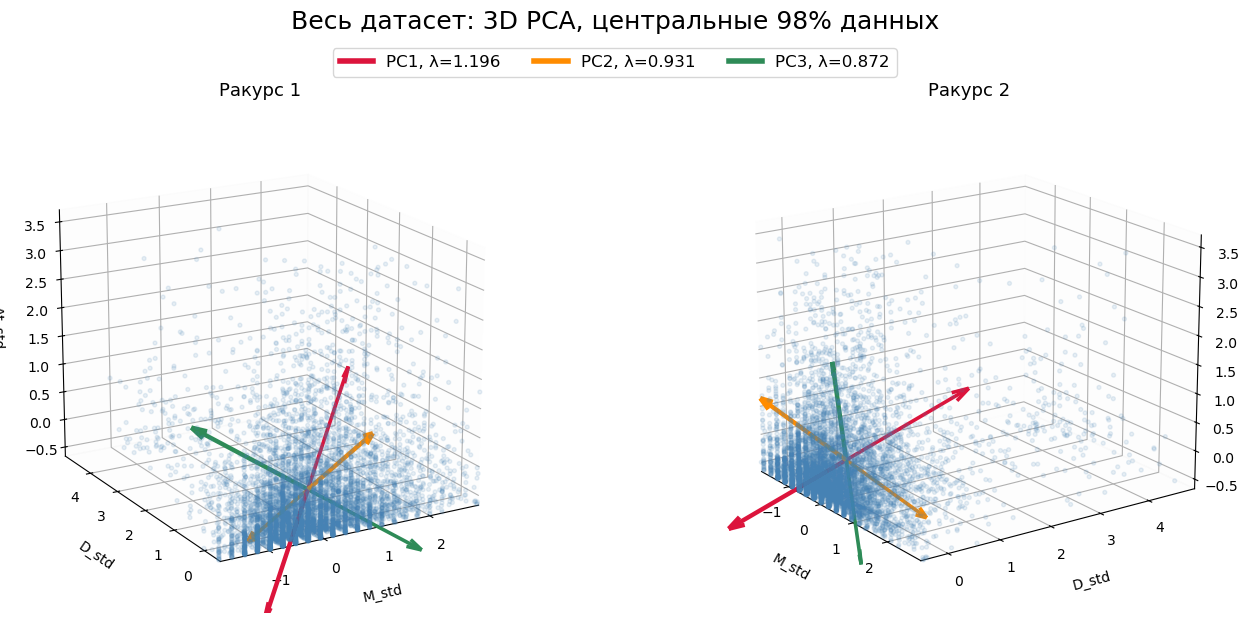

In [57]:
plot_pca_3d_two_views(df)

In [68]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import itertools
import numpy as np
import matplotlib.pyplot as plt


def get_pca(X):
    R = np.corrcoef(X, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(R)

    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    return eigvals, eigvecs


def align_pca_to_reference(eigvals, eigvecs, ref_eigvecs):
    best_perm = None
    best_score = -np.inf

    for perm in itertools.permutations(range(3)):
        score = sum(
            abs(np.dot(ref_eigvecs[:, i], eigvecs[:, perm[i]]))
            for i in range(3)
        )
        if score > best_score:
            best_score = score
            best_perm = perm

    eigvals_aligned = eigvals[list(best_perm)]
    eigvecs_aligned = eigvecs[:, list(best_perm)]

    for i in range(3):
        if np.dot(ref_eigvecs[:, i], eigvecs_aligned[:, i]) < 0:
            eigvecs_aligned[:, i] *= -1

    return eigvals_aligned, eigvecs_aligned


def plot_pca_three_sets_aligned(
    df,
    df_first,
    df_second,
    elev=18,
    azim=-35,
    sample_size=3000,
    q_low=0.01,
    q_high=0.99,
    arrow_scale=2.3
):
    cols = ["magn", "deep", "dt"]

    # общая стандартизация по полному датасету
    X_full_raw = df[cols].values.astype(float)
    X1_raw = df_first[cols].values.astype(float)
    X2_raw = df_second[cols].values.astype(float)

    mean = X_full_raw.mean(axis=0)
    std = X_full_raw.std(axis=0, ddof=1)

    X_full = (X_full_raw - mean) / std
    X1 = (X1_raw - mean) / std
    X2 = (X2_raw - mean) / std

    eigvals_full, eigvecs_full = get_pca(X_full)
    eigvals_1, eigvecs_1 = get_pca(X1)
    eigvals_2, eigvecs_2 = get_pca(X2)

    eigvals_1, eigvecs_1 = align_pca_to_reference(eigvals_1, eigvecs_1, eigvecs_full)
    eigvals_2, eigvecs_2 = align_pca_to_reference(eigvals_2, eigvecs_2, eigvecs_full)

    # общие пределы осей
    x_min, x_max = np.quantile(X_full[:, 0], [q_low, q_high])
    y_min, y_max = np.quantile(X_full[:, 1], [q_low, q_high])
    z_min, z_max = np.quantile(X_full[:, 2], [q_low, q_high])

    def crop_and_sample(X):
        mask = (
            (X[:, 0] >= x_min) & (X[:, 0] <= x_max) &
            (X[:, 1] >= y_min) & (X[:, 1] <= y_max) &
            (X[:, 2] >= z_min) & (X[:, 2] <= z_max)
        )

        X_plot = X[mask]

        if len(X_plot) > sample_size:
            idx = np.random.choice(len(X_plot), sample_size, replace=False)
            X_plot = X_plot[idx]

        return X_plot

    X_full_plot = crop_and_sample(X_full)
    X1_plot = crop_and_sample(X1)
    X2_plot = crop_and_sample(X2)

    fig = plt.figure(figsize=(19, 7.6))

    vector_colors = ["crimson", "darkorange", "seagreen"]

    configs = [
        (X_full_plot, eigvals_full, eigvecs_full, "Весь датасет", "steelblue"),
        (X1_plot, eigvals_1, eigvecs_1, "Первая половина", "royalblue"),
        (X2_plot, eigvals_2, eigvecs_2, "Вторая половина", "mediumpurple"),
    ]

    for i, (X_plot, eigvals, eigvecs, title, point_color) in enumerate(configs, 1):
        ax = fig.add_subplot(1, 3, i, projection="3d")

        ax.scatter(
            X_plot[:, 0],
            X_plot[:, 1],
            X_plot[:, 2],
            s=8,
            alpha=0.12,
            color=point_color
        )

        for k in range(3):
            v = eigvecs[:, k]
            L = arrow_scale * np.sqrt(eigvals[k])

            ax.quiver(
                0, 0, 0,
                L * v[0], L * v[1], L * v[2],
                color=vector_colors[k],
                linewidth=3.0,
                arrow_length_ratio=0.12
            )

            ax.quiver(
                0, 0, 0,
                -L * v[0], -L * v[1], -L * v[2],
                color=vector_colors[k],
                linewidth=2.4,
                arrow_length_ratio=0.12
            )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_zlim(z_min, z_max)

        ax.set_xlabel("M_std", labelpad=8)
        ax.set_ylabel("D_std", labelpad=8)
        ax.set_zlabel("Δt_std", labelpad=8)

        ax.xaxis.pane.set_alpha(0.08)
        ax.yaxis.pane.set_alpha(0.08)
        ax.zaxis.pane.set_alpha(0.08)

        ax.grid(True)
        ax.set_box_aspect((x_max - x_min, y_max - y_min, z_max - z_min))
        ax.view_init(elev=elev, azim=azim)

        ax.set_title(
            title + "\n" +
            f"λ = ({eigvals[0]:.3f}, {eigvals[1]:.3f}, {eigvals[2]:.3f})",
            fontsize=12,
            pad=14
        )

    handles = [
        Line2D([0], [0], color=vector_colors[0], lw=4, label="направление PC1"),
        Line2D([0], [0], color=vector_colors[1], lw=4, label="направление PC2"),
        Line2D([0], [0], color=vector_colors[2], lw=4, label="направление PC3"),
    ]

    fig.suptitle(
        "3D PCA: сравнение полного датасета и двух половин\n"
        "общий ракурс, общая стандартизация",
        fontsize=18,
        y=0.965
    )

    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=3,
        frameon=True,
        bbox_to_anchor=(0.5, 0.84),
        fontsize=10
    )

    plt.subplots_adjust(
        top=0.72,
        wspace=0.05
    )

    plt.show()

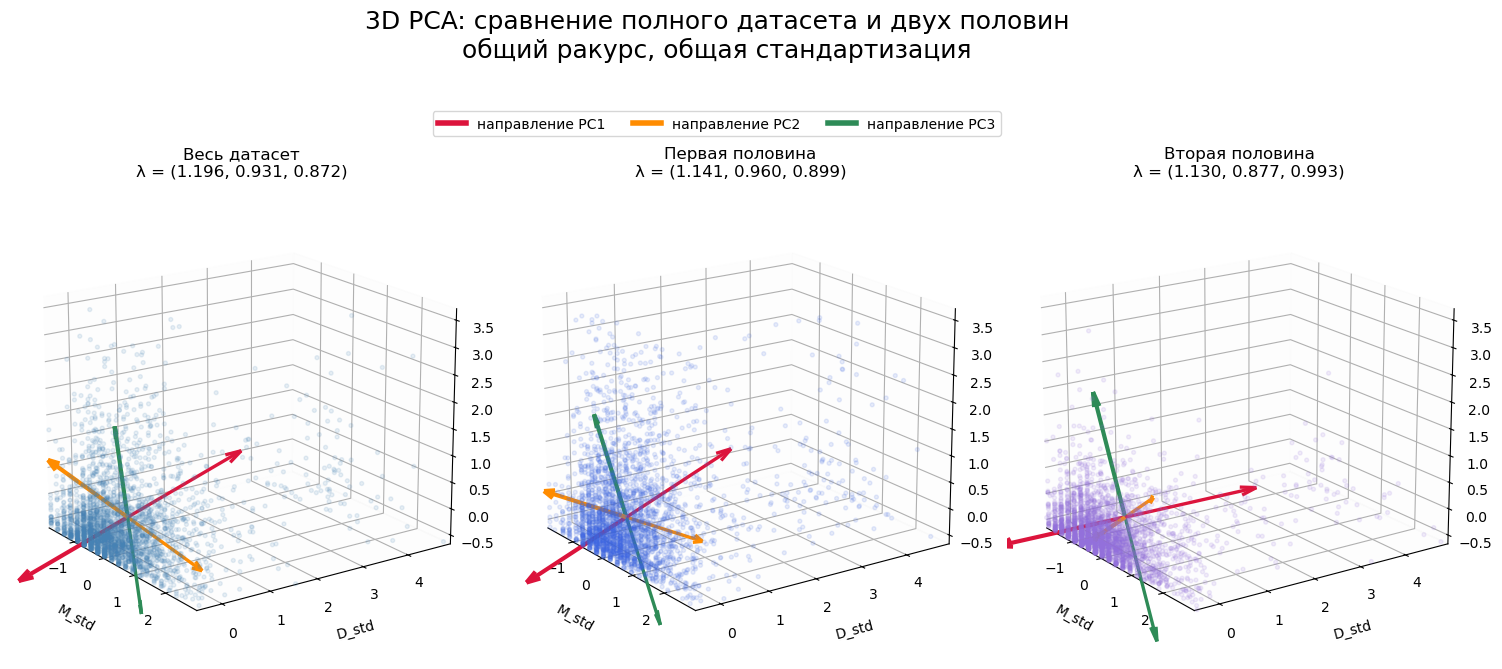

In [69]:
plot_pca_three_sets_aligned(
    df,
    df_first,
    df_second,
    elev=18,
    azim=-35
)

#### 3. Корреляциооная функция (самая частая глубина)

In [45]:
deep_step = 5

deep_bins = np.arange(
    np.floor(df["deep"].min() / deep_step) * deep_step,
    np.ceil(df["deep"].max() / deep_step) * deep_step + deep_step,
    deep_step
)

deep_counts, _ = np.histogram(df["deep"], bins=deep_bins)

popular_deep_idx = np.argmax(deep_counts)

popular_deep_left = deep_bins[popular_deep_idx]
popular_deep_right = deep_bins[popular_deep_idx + 1]

print("Самый популярный интервал глубины:")
print(f"{popular_deep_left} - {popular_deep_right} км")
print("Количество событий:", deep_counts[popular_deep_idx])
print("Доля от всех событий:", deep_counts[popular_deep_idx] / len(df))

Самый популярный интервал глубины:
10.0 - 15.0 км
Количество событий: 19647
Доля от всех событий: 0.3457092080026746


In [46]:
df_depth_slice = df[
    (df["deep"] >= popular_deep_left) &
    (df["deep"] < popular_deep_right)
].copy()

print("Размер выборки в самом популярном слое:", len(df_depth_slice))

Размер выборки в самом популярном слое: 19647


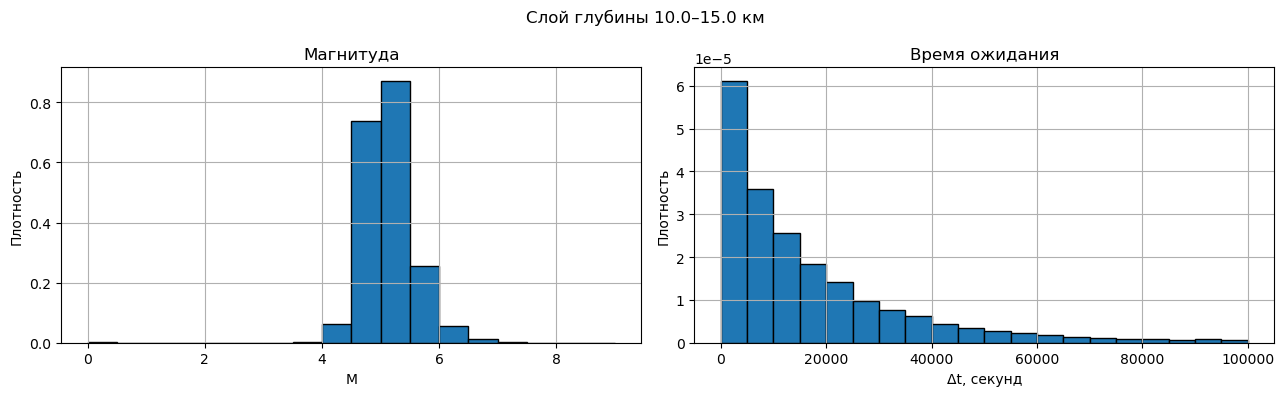

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_depth_slice["magn"], bins=magn_bins, density=True, edgecolor="black")
axes[0].set_title("Магнитуда")
axes[0].set_xlabel("M")
axes[0].set_ylabel("Плотность")
axes[0].grid(True)

axes[1].hist(
    df_depth_slice.loc[df_depth_slice["dt"] <= 100_000, "dt"],
    bins=np.arange(0, 100_000 + dt_step, dt_step),
    density=True,
    edgecolor="black"
)
axes[1].set_title("Время ожидания")
axes[1].set_xlabel("Δt, секунд")
axes[1].set_ylabel("Плотность")
axes[1].grid(True)

plt.suptitle(f"Слой глубины {popular_deep_left}–{popular_deep_right} км")
plt.tight_layout()
plt.show()

In [54]:
counts_2d_slice, magn_edges, dt_edges = np.histogram2d(
    df_depth_slice["magn"],
    df_depth_slice["dt"],
    bins=[magn_bins, dt_bins]
)

# нормируем: сумма всех ячеек равна 1
f_slice = counts_2d_slice / counts_2d_slice.sum()

print("Размерность f_slice:", f_slice.shape)
print("Сумма вероятностей:", f_slice.sum())

Размерность f_slice: (18, 398)
Сумма вероятностей: 1.0


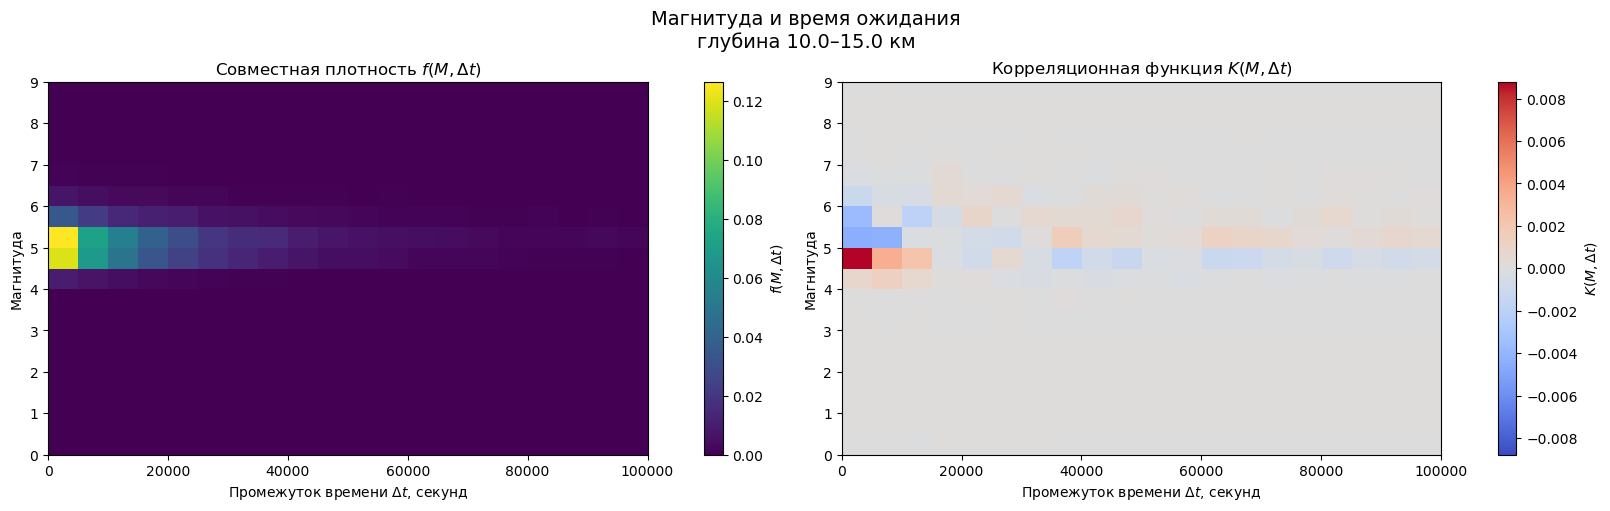

In [93]:
# если f_slice, g_slice, h_slice, independent_slice, K_slice ещё не посчитаны:
g_slice = f_slice.sum(axis=1)
h_slice = f_slice.sum(axis=0)
independent_slice = np.outer(g_slice, h_slice)
K_slice = f_slice - independent_slice

dt_limit_f = 100_000
dt_limit_K = 100_000

dt_mask_f = dt_bins[:-1] < dt_limit_f
dt_mask_K = dt_bins[:-1] < dt_limit_K

f_plot = f_slice[:, dt_mask_f]
K_plot = K_slice[:, dt_mask_K]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

# 1. Совместная плотность
im0 = axes[0].imshow(
    f_plot,
    origin="lower",
    aspect="auto",
    extent=[
        dt_bins[:-1][dt_mask_f][0],
        dt_bins[:-1][dt_mask_f][-1] + dt_step,
        magn_bins[0],
        magn_bins[-1]
    ]
)
axes[0].set_title("Совместная плотность $f(M, \\Delta t)$")
axes[0].set_xlabel("Промежуток времени $\\Delta t$, секунд")
axes[0].set_ylabel("Магнитуда")
fig.colorbar(im0, ax=axes[0], label="$f(M, \\Delta t)$")

# 2. Корреляционная функция
vmax = np.max(np.abs(K_plot))

im1 = axes[1].imshow(
    K_plot,
    origin="lower",
    aspect="auto",
    extent=[
        dt_bins[:-1][dt_mask_K][0],
        dt_bins[:-1][dt_mask_K][-1] + dt_step,
        magn_bins[0],
        magn_bins[-1]
    ],
    vmin=-vmax,
    vmax=vmax,
    cmap="coolwarm"
)
axes[1].set_title("Корреляционная функция $K(M, \\Delta t)$")
axes[1].set_xlabel("Промежуток времени $\\Delta t$, секунд")
axes[1].set_ylabel("Магнитуда")
fig.colorbar(im1, ax=axes[1], label="$K(M, \\Delta t)$")

fig.suptitle(
    f"Магнитуда и время ожидания\nглубина {popular_deep_left}–{popular_deep_right} км",
    fontsize=14
)

plt.show()

In [62]:
max_K_idx = np.unravel_index(
    np.argmax(np.abs(K_slice)),
    K_slice.shape
)

i, j = max_K_idx

print("Максимальное отклонение от независимости:")
print("Магнитуда:", magn_bins[i], "-", magn_bins[i + 1])
print("Δt:", dt_bins[j], "-", dt_bins[j + 1], "сек")
print("K:", K_slice[i, j])
print("f:", f_slice[i, j])
print("g*h:", independent_slice[i, j])

Максимальное отклонение от независимости:
Магнитуда: 4.5 - 5.0
Δt: 0.0 - 5000.0 сек
K: 0.008792724026774515
f: 0.1197638316282384
g*h: 0.11097110760146389


#### 3. Корреляциооная функция весь датасет

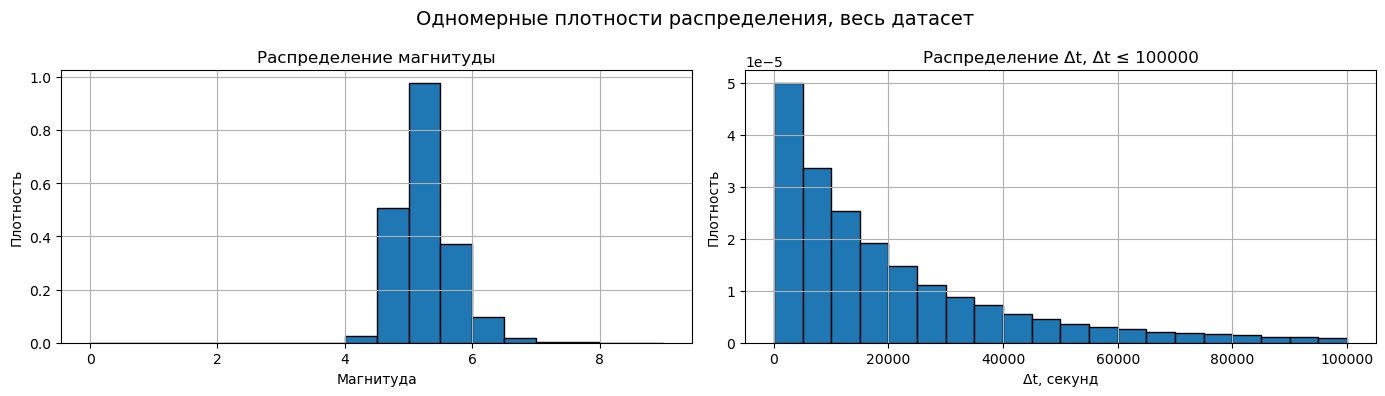

In [86]:
dt_limit = 100_000

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Магнитуда
axes[0].hist(
    df["magn"],
    bins=magn_bins,
    density=True,
    edgecolor="black"
)

axes[0].set_xlabel("Магнитуда")
axes[0].set_ylabel("Плотность")
axes[0].set_title("Распределение магнитуды")
axes[0].grid(True)

# Время ожидания
axes[1].hist(
    df.loc[df["dt"] <= dt_limit, "dt"],
    bins=np.arange(0, dt_limit + dt_step, dt_step),
    density=True,
    edgecolor="black"
)

axes[1].set_xlabel("Δt, секунд")
axes[1].set_ylabel("Плотность")
axes[1].set_title(f"Распределение Δt, Δt ≤ {dt_limit}")
axes[1].grid(True)

fig.suptitle(
    "Одномерные плотности распределения, весь датасет",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [63]:
counts_2d_full, magn_edges, dt_edges = np.histogram2d(
    df["magn"],
    df["dt"],
    bins=[magn_bins, dt_bins]
)

f_full_md = counts_2d_full / counts_2d_full.sum()

print("Размерность f_full_md:", f_full_md.shape)
print("Сумма вероятностей:", f_full_md.sum())

Размерность f_full_md: (18, 398)
Сумма вероятностей: 1.0


In [65]:
g_full_md = f_full_md.sum(axis=1)  # распределение магнитуды
h_full_md = f_full_md.sum(axis=0)  # распределение dt

independent_full_md = np.outer(g_full_md, h_full_md)

print("Размерность independent_full_md:", independent_full_md.shape)
print("Сумма independent_full_md:", independent_full_md.sum())

Размерность independent_full_md: (18, 398)
Сумма independent_full_md: 1.0


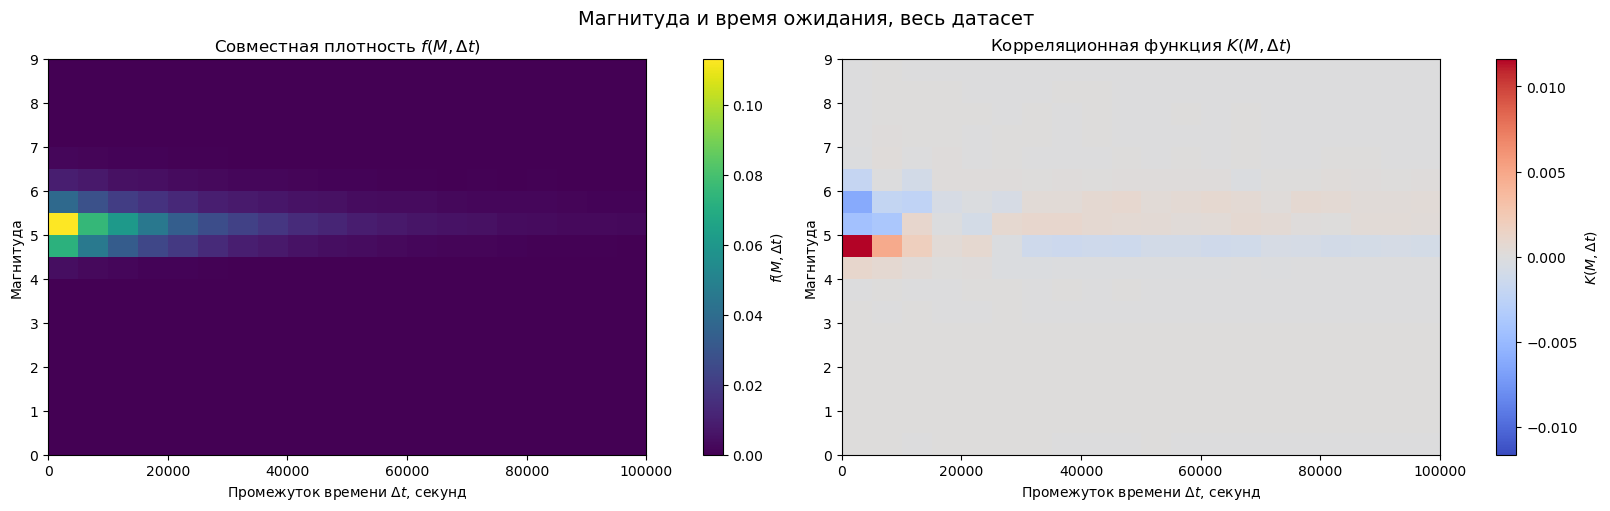

In [90]:
# если ещё не посчитано:
g_full_md = f_full_md.sum(axis=1)
h_full_md = f_full_md.sum(axis=0)
independent_full_md = np.outer(g_full_md, h_full_md)
K_full_md = f_full_md - independent_full_md

dt_limit = 100_000
dt_mask = dt_bins[:-1] < dt_limit

f_plot = f_full_md[:, dt_mask]
K_plot = K_full_md[:, dt_mask]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

# 1. Совместная плотность
im0 = axes[0].imshow(
    f_plot,
    origin="lower",
    aspect="auto",
    extent=[
        dt_bins[:-1][dt_mask][0],
        dt_bins[:-1][dt_mask][-1] + dt_step,
        magn_bins[0],
        magn_bins[-1]
    ]
)
axes[0].set_title("Совместная плотность $f(M, \\Delta t)$")
axes[0].set_xlabel("Промежуток времени $\\Delta t$, секунд")
axes[0].set_ylabel("Магнитуда")
fig.colorbar(im0, ax=axes[0], label="$f(M, \\Delta t)$")

# 2. Корреляционная функция
vmax = np.max(np.abs(K_plot))

im1 = axes[1].imshow(
    K_plot,
    origin="lower",
    aspect="auto",
    extent=[
        dt_bins[:-1][dt_mask][0],
        dt_bins[:-1][dt_mask][-1] + dt_step,
        magn_bins[0],
        magn_bins[-1]
    ],
    vmin=-vmax,
    vmax=vmax,
    cmap="coolwarm"
)
axes[1].set_title("Корреляционная функция $K(M, \\Delta t)$")
axes[1].set_xlabel("Промежуток времени $\\Delta t$, секунд")
axes[1].set_ylabel("Магнитуда")
fig.colorbar(im1, ax=axes[1], label="$K(M, \\Delta t)$")

fig.suptitle("Магнитуда и время ожидания, весь датасет", fontsize=14)

plt.show()

In [69]:
comparison_K = pd.DataFrame({
    "Набор данных": [
        "Самый популярный слой глубины",
        "Весь датасет"
    ],
    "max |K|": [
        np.abs(K_slice).max(),
        np.abs(K_full_md).max()
    ],
    "max K": [
        K_slice.max(),
        K_full_md.max()
    ],
    "min K": [
        K_slice.min(),
        K_full_md.min()
    ]
})

comparison_K

,Набор данных,max |K|,max K,min K
0,Самый популярный слой глубины,0.008793,0.008793,-0.004449
1,Весь датасет,0.011612,0.011612,-0.006156


### Обсуждение корреляционной функции

Корреляционная функция $K(M, \Delta t)$ была построена двумя способами: по всему набору данных и отдельно в наиболее популярном сечении по глубине.

По графикам видно, что для всего датасета корреляционная функция сильнее отличается от нуля, чем в фиксированном слое глубины. Это означает, что при рассмотрении всех событий вместе магнитуда и время ожидания демонстрируют более заметное отклонение от независимости.

Возможное объяснение состоит в том, что глубина играет роль скрытого параметра. Даже если внутри фиксированного слоя глубины магнитуда и промежуток времени почти независимы, при объединении событий с разных глубин может появиться видимая зависимость между ними.

Формально это можно понимать так: полное совместное распределение по магнитуде и времени является смесью распределений по разным глубинам:

$P(M, \Delta t) = \sum_D P(D) P(M, \Delta t \mid D).$

Если распределения $M$ и $\Delta t$ меняются при изменении глубины, то после суммирования по всем глубинам может возникнуть ненулевая корреляционная функция $K(M, \Delta t)$, даже если внутри отдельного слоя глубины эта зависимость слабая.

Таким образом, более сильное отличие $K(M, \Delta t)$ от нуля на полном датасете может быть связано не только с прямой зависимостью магнитуды от времени ожидания, но и с неоднородностью данных по глубине. Это согласуется с предыдущими результатами: глубина заметно меняется между разными частями выборки и может влиять на структуру распределения остальных параметров.